Comparing different methods for calculating halo accretion rate to see if that might be biasing our results

In [3]:
from escripts import eMCMC
from escripts import edata
from escripts import eplots
import zeus21
import math

In [4]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['HST data, Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [5]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz':{'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [6]:
def Yung_accretion(M, z):

    return beta(z)*(M/1e12*E(z))**alpha(z)

In [7]:
def E(z, OmegaL = 0.6900259954953076, OmegaM = 0.3098830430481206):
    return np.sqrt(OmegaL + (OmegaM*(1+z)**3))

In [8]:
def beta(z):
    a = (1+z)**-1

    return 10**(2.578 - (0.989*a) - (1.545*(a**2)))

In [9]:
def alpha(z):
    a = (1+z)**-1

    return 0.858 + (1.554 * a) - (1.176*(a**2))

In [10]:
Ms = np.logspace(9, 12, 10)
z = 12

Y_acc = Yung_accretion(Ms, z)
base_acc = zeus21.sfrd.dMh_dt(my_UVLF.Astro_Parameters, my_UVLF.CosmoParams, my_UVLF.HMFintclass, Ms, z)

# Comparison at one redshift

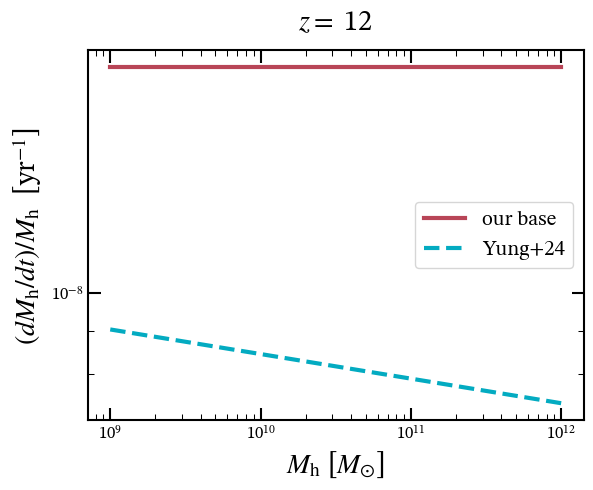

In [91]:
fig, ax = plt.subplots()

plt.plot(Ms, base_acc/Ms, label = 'our base')
plt.plot(Ms, Y_acc/Ms, label = 'Yung+24', color = eplots.turquoise, ls = 'dashed')

ax.set_xscale('log')

plt.title(fr'$z =$ {z}')

ax.set_yscale('log')

ax.set_ylabel(r'$(dM_{\rm{h}}/dt)/M_{\rm{h}}$  [yr$^{-1}$]')
ax.set_xlabel(r'$M_{\rm{h}}$ [$M_{\odot}$]')

ax.legend()

# Comparison across redshifts at different halo masses

In [178]:
Mhtab = np.arange(9, 11.5, 0.75)
cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)
zs = np.linspace(4, 13, 100)

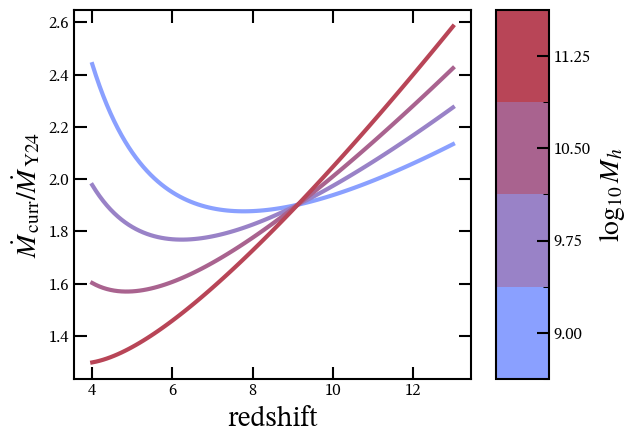

In [179]:
fig, ax = plt.subplots()
for Mh in Mhtab:
    M_test = np.array([10**Mh], dtype = float)
    Y_acc = Yung_accretion(M_test, zs)
    base_acc = zeus21.sfrd.dMh_dt(my_UVLF.Astro_Parameters, my_UVLF.CosmoParams, my_UVLF.HMFintclass, M_test, zs)

    frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min()) 
    color = cmap(frac)
    plt.plot(zs, base_acc/Y_acc, color = color, ls = 'solid')

ax.set_ylabel(r'$\dot M_{\rm{curr}} / \dot M_{\rm{Y24}}$')
ax.set_xlabel('redshift')
cbar = fig.colorbar(sm, ax = ax, boundaries=boundaries, ticks=Mhtab, aspect = 7)
cbar.set_label(r'$\log_{10}{M_h}$')

In [ ]:
# fig.savefig('/Users/eb35267/Desktop/code/figures/Yung24_vs_our_accretion.png')

# Comparing epsilon

In [ ]:
fiducial = [0.531, -0.001, 11.712, -0.057, -1.338, -0.113, 0.486, 0.229,
-0.152, 0.678]
eps_og = 10**np.array([my_UVLF.time_evolution(fiducial, z)[-2] for z in zs])
Mc = 10**np.array([my_UVLF.time_evolution(fiducial, z)[2] for z in zs])

In [188]:
ratio = zeus21.sfrd.dMh_dt(my_UVLF.Astro_Parameters, my_UVLF.CosmoParams, my_UVLF.HMFintclass, Mc, zs) / Yung_accretion(Mc, zs)

In [189]:
eps_new = eps_og * ratio

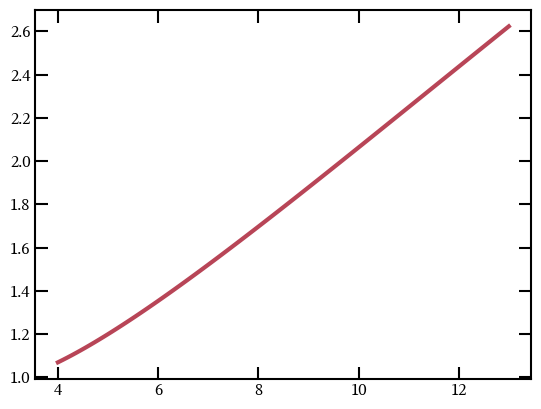

In [214]:
plt.plot(zs, ratio)

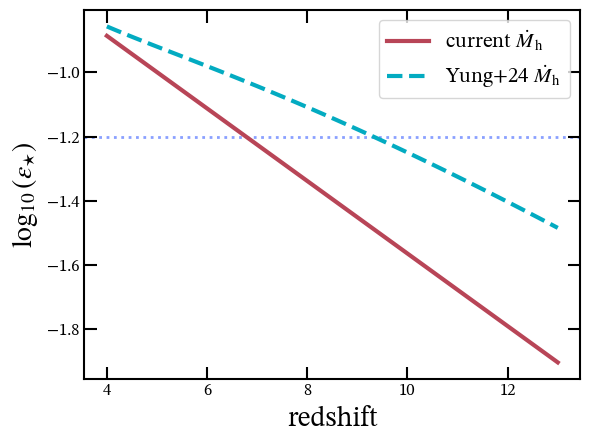

In [211]:
fig, ax = plt.subplots()

plt.plot(zs, np.log10(eps_og), label = r'current $\dot M_{\rm{h}}$')
plt.plot(zs, np.log10(eps_new), ls = 'dashed', label = r'Yung+24 $\dot M_{\rm{h}}$')
ax.axhline(-1.2, zorder = 0, lw = 2, ls = 'dotted', color = eplots.periwinkle)

ax.set_ylabel(r'$\log_{10}(\epsilon_{\star})$')
ax.set_xlabel(r'redshift')

ax.legend()

In [212]:
fig.savefig('/Users/eb35267/Desktop/code/figures/new_eps_star.png')

# Testing Yung+24 at lower $z$

In [11]:
def RP16_accretion(M, z, h = 0.6781):
    a = (1+z)**-1
    M_12 = 1e12/h

    beta = 10**(2.437-(1.857*a)+(0.685*a**2))
    alpha = 1.120 - (0.609*a) + (0.097*a**2)
    gamma = 0.917 + (0.845*a) - (0.532*a**2)
    
    return beta * ((M/M_12)**alpha + (M/M_12)**gamma) * E(z)

(10000000000.0, 1000000000000000.0)

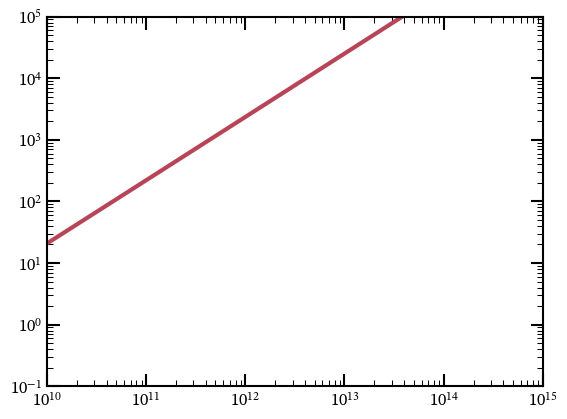

In [16]:
h = 0.6781
z=8
Ms = np.logspace(9, 15, 10)
plt.loglog(Ms/h, RP16_accretion(Ms,z))
plt.ylim(1e-1, 1e5)
plt.xlim(1e10, 1e15)

In [70]:
Ms = np.logspace(9, 12, 10)
z = 8

In [71]:
RP_acc = RP16_accretion(Ms, z)
Y_acc = Yung_accretion(Ms, z)

(1e-12, 1e-07)

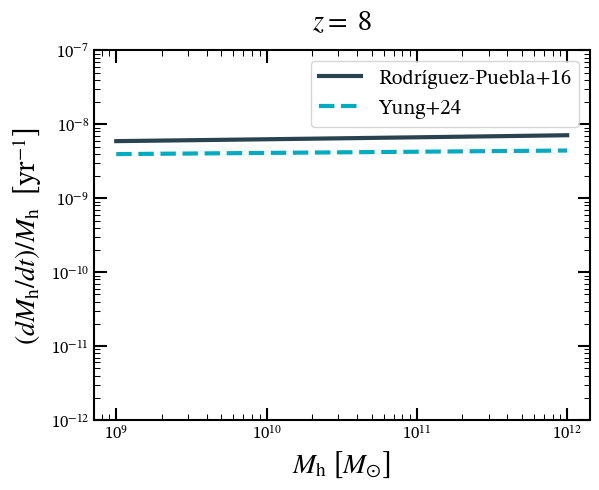

In [73]:
fig, ax = plt.subplots()

plt.plot(Ms, 3*h*RP_acc/Ms, label = 'Rodríguez-Puebla+16', color = eplots.navy)
plt.plot(Ms, Y_acc/Ms, label = 'Yung+24', color = eplots.turquoise, ls = 'dashed')

ax.set_xscale('log')

plt.title(fr'$z =$ {z}')

ax.set_yscale('log')

ax.set_ylabel(r'$(dM_{\rm{h}}/dt)/M_{\rm{h}}$  [yr$^{-1}$]')
ax.set_xlabel(r'$M_{\rm{h}}$ [$M_{\odot}$]')

ax.legend()

ax.set_ylim(1e-12, 1e-7)

In [74]:
Mhtab = np.arange(9, 11.5, 0.75)
cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)
zs = np.linspace(4, 9, 100)

Text(7.5, 0.75, 'Y+24')

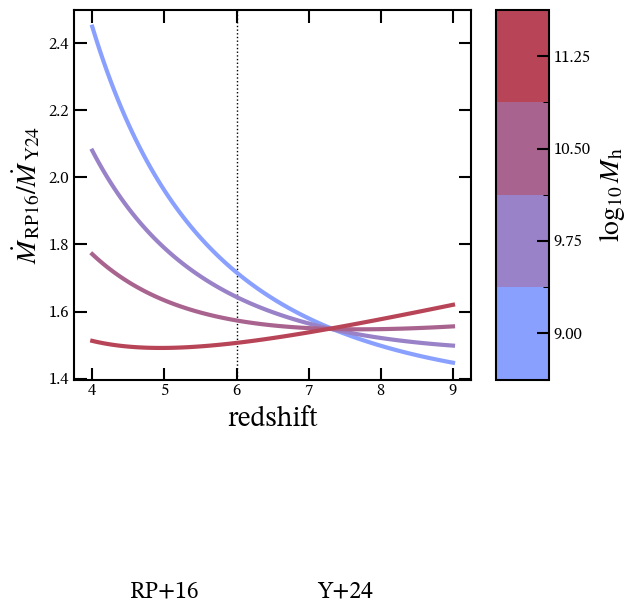

In [75]:
fig, ax = plt.subplots()
for Mh in Mhtab:
    M_test = np.array([10**Mh], dtype = float)
    Y_acc = Yung_accretion(M_test, zs)
    RP_acc = 3*h*RP16_accretion(M_test, zs)

    frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min()) 
    color = cmap(frac)
    plt.plot(zs, RP_acc/Y_acc, color = color, ls = 'solid')

ax.set_ylabel(r'$\dot M_{\rm{RP16}} / \dot M_{\rm{Y24}}$')
ax.set_xlabel('redshift')
cbar = fig.colorbar(sm, ax = ax, boundaries=boundaries, ticks=Mhtab, aspect = 7)
cbar.set_label(r'$\log_{10}{M_{\rm{h}}}$')

ax.axvline(6, zorder = 0, color = 'black', lw = 1, ls = 'dotted')
ax.text(5, 0.75, 'RP+16', ha = 'center')
ax.text(7.5, 0.75, 'Y+24', ha = 'center')

In [36]:
fig.savefig('/Users/eb35267/Desktop/code/figures/RP16_Y24_comparison.png')